# Working with Spatial-Temporal Data: Geolocation and Transformation

This section will introduce several important concepts and methods related to geolocation and transformation.

# Setup

We begin by importing the libraries we'll need.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

import skmob
from skmob.preprocessing import detection, clustering

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)
import warnings
warnings.simplefilter("ignore")

*Note: As of the time of writing, some of the functions from `skmob` that we'll be using in this section will only work with `geopandas` version 0.14.4 and below. Run the following code cell to check your version of `geopandas`.*

In [2]:
gpd.__version__

'0.14.4'

*If your version of `geopandas` is higher than 0.14.4, try uninstalling it using the command `conda uninstall geopandas` and then reinstalling it using the command `conda install "geopandas<=0.14.4" -c conda-forge`.*

Once the libraries are imported, we read in the raw data and clean it as before (see the previous section for details and rationale):

In [3]:
os.chdir('/Users/yingli/Development/TopicsInDataScience/')
events = pd.read_csv("Galapagos Tortoise Movement Ecology Programme_2009-2018.csv", sep=',', parse_dates=[2])
new_cols = pd.Series(events.columns.values).str.replace(pat = r"[-:]", repl="_", regex=True)
tortoise = events.set_axis(labels = new_cols, axis =1)
tortoise.drop(tortoise.index[tortoise["manually_marked_outlier"].notna()], inplace = True)
tortoise.drop(columns =["manually_marked_outlier"], inplace=True)
tortoise.drop(index = tortoise.index[tortoise.isna().any(axis=1)], inplace=True)
cols = ['event_id', 'timestamp', 'location_long', 'location_lat',
       'eobs_temperature', 'ground_speed', 'heading', 'height_above_ellipsoid',
       'individual_local_identifier', 'individual_taxon_canonical_name']
tortoise.drop(columns=tortoise.columns.difference(cols), inplace=True)

## Working with Timezone

According to the research paper, tortoises tend to be sedentary at night, so the movement observations were taken during the daytime (5 am to 7 pm). The timestamps in the current data are implicitly in UTC timezone, but the timezone is not explicitly attached to the data.

To calculate time differences, we need to sort by tortoise and then by time. But in order to sort by time, we need to use local time (UTC/Pacific) instead of UTC, because the activities are associated with the concept of daytime.

We accomplish this in several steps:

In [4]:
# create a new timestamp column that is explicitly in UTC
tortoise.insert(loc = 2, column = "timestamp_UTC",
    value = tortoise['timestamp'].apply(lambda x: x.tz_localize(tz='UTC'))
)
# create a new column for local time
tortoise.insert(loc = 3, column = "timestamp_local", 
    value = tortoise["timestamp_UTC"].apply(lambda x: x.tz_convert(tz='US/Pacific'))
)
# sort by tortoise and then by time
tortoise.sort_values(by = ["individual_local_identifier", "timestamp_local"], inplace=True)

# calculate the minute gaps between consecutive tracking events
tortoise.insert(loc = 4, column = "minute_diff", 
    value = tortoise.groupby(['individual_local_identifier'])["timestamp_local"].diff()\
        .apply(lambda x: x/np.timedelta64(1, 'm')).fillna(0).astype('int64')
)

Here is what one of the local timestamps looks like:

In [5]:
tortoise.timestamp_local[1].tzinfo, tortoise.timestamp_local[1]

(<DstTzInfo 'US/Pacific' PDT-1 day, 17:00:00 DST>,
 Timestamp('2010-09-23 10:00:49.998000-0700', tz='US/Pacific'))

As in the previous section, we also create several new columns to represent different parts of the timestamp such as the year, month, and day. This time, however, we derive this information from the local time instead of UTC time.

In [6]:
tortoise['year'] = tortoise["timestamp_local"].dt.year
tortoise['month'] = tortoise["timestamp_local"].dt.month
tortoise['date'] = tortoise["timestamp_local"].dt.date

# we don't really need the day, hour, etc. for now
#tortoise['day'] = tortoise["timestamp_local"].dt.day
#tortoise['hour'] = tortoise["timestamp_local"].dt.hour
#tortoise['weekday'] = tortoise["timestamp_local"].dt.weekday
#tortoise['year_month'] = tortoise["timestamp_local"].apply(lambda t: t.strftime("%Y-%m"))
#tortoise['year_week'] = tortoise["timestamp_local"].apply(lambda t: t.strftime("%Y-%W")) 

Having made these changes, let's take a look at the data again:

In [7]:
tortoise.head(30)

,event_id,timestamp,timestamp_UTC,timestamp_local,minute_diff,location_long,location_lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,individual_local_identifier,year,month,date
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290188,46119278,2010-09-17 18:00:58.001,2010-09-17 18:00:58.001000+00:00,2010-09-17 11:00:58.001000-07:00,59,-90.242230,-0.635563,19,0.21,19.01,143.6,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290189,46119279,2010-09-17 19:00:56.001,2010-09-17 19:00:56.001000+00:00,2010-09-17 12:00:56.001000-07:00,59,-90.242210,-0.635515,22,0.15,359.14,171.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290190,46119280,2010-09-17 20:00:29.000,2010-09-17 20:00:29+00:00,2010-09-17 13:00:29-07:00,59,-90.242227,-0.635356,19,0.75,19.66,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290191,46119281,2010-09-17 21:00:56.000,2010-09-17 21:00:56+00:00,2010-09-17 14:00:56-07:00,60,-90.242101,-0.635276,17,0.08,342.75,160.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290192,46119282,2010-09-17 22:01:05.000,2010-09-17 22:01:05+00:00,2010-09-17 15:01:05-07:00,60,-90.242075,-0.635253,17,0.09,245.10,237.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290193,46119283,2010-09-17 23:00:49.999,2010-09-17 23:00:49.999000+00:00,2010-09-17 16:00:49.999000-07:00,59,-90.242144,-0.635304,16,0.16,0.66,165.0,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290194,46119284,2010-09-18 00:00:55.998,2010-09-18 00:00:55.998000+00:00,2010-09-17 17:00:55.998000-07:00,60,-90.242356,-0.635129,11,0.28,29.49,175.7,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290195,46119285,2010-09-18 01:01:26.000,2010-09-18 01:01:26+00:00,2010-09-17 18:01:26-07:00,60,-90.242150,-0.635272,9,0.22,322.44,150.7,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290196,46119286,2010-09-18 11:00:56.000,2010-09-18 11:00:56+00:00,2010-09-18 04:00:56-07:00,599,-90.242106,-0.635292,6,0.18,3.28,159.3,Chelonoidis donfaustoi,Alison,2010,9,2010-09-18


Notice how some of the `minute_diff` values are larger than an hour. We can use the `value_counts()` function to get a better sense of the values in this column.

In [8]:
tortoise.minute_diff.value_counts()

minute_diff
59        636186
60        624193
0         159167
15         90186
600        52443
           ...  
222650         1
782            1
19979          1
177120         1
60117          1
Name: count, Length: 623, dtype: int64

## Computing Distance Between Coordinates

Next, we'll take a look at how to calculate distance between coordinates. As before, we use the *Chelonoidis donfaustoi* tortoise Alison as an example.

In [9]:
alison = tortoise[tortoise["individual_local_identifier"] == "Alison"]

We can use the following code to compare the minimum and maximum values for each column for Alison:

In [10]:
temp_df = pd.DataFrame(alison.min()).set_axis(labels = ["min_attr"], axis =1)
temp_df["max_attr"] = alison.max().values
temp_df

,min_attr,max_attr
event_id,46119247,7513055046
timestamp,2010-09-17 17:01:25.998000,2018-10-01 16:00:29.998000
timestamp_UTC,2010-09-17 17:01:25.998000+00:00,2018-10-01 16:00:29.998000+00:00
timestamp_local,2010-09-17 10:01:25.998000-07:00,2018-10-01 09:00:29.998000-07:00
minute_diff,0,150660
location_long,-90.27502,-90.239427
location_lat,-0.656178,-0.629772
eobs_temperature,-2,35
ground_speed,0.0,61.1
heading,0.0,359.79


### Haversine Distances

The haversine formula is a very accurate way of computing great-circle distances between two points on the surface of a sphere using the latitude and longitude of the two points. Let $\phi_{i}$ be the latitude of point $i$ in radians, and let $\lambda_{i}$ be the longitude of point $i$ in radians, for $i=1,2$. Then the distance between points 1 and 2 is given by 

$$ d = 2r\arcsin(\sqrt{a}) $$

where $a$, the haversine of the central angle between the two points, is defined as

$$ a = \sin^2(\frac{\Delta{\phi}}{2}) + \cos(\phi_{1}) * \cos(\phi_{2}) * \sin^2(\frac{\Delta{\lambda}}{2})\,. $$

### Haversine with Scikit-Learn

Here is an example using `sklearn`'s `haversine_distances()` on two coordinate pairs from `alison`. First, we pick two points:

In [11]:
p1 = alison[["location_lat", "location_long"]].iloc[10000]
p2 = alison[["location_lat", "location_long"]].iloc[3400]
(p1,p2)

(location_lat     -0.635761
 location_long   -90.244064
 Name: 1300671, dtype: float64,
 location_lat     -0.635083
 location_long   -90.243592
 Name: 1293719, dtype: float64)

We convert the points to radians, then compute the haversine distance:

In [12]:
from sklearn.metrics.pairwise import haversine_distances
from math import radians
p1_in_radians = p1.apply(lambda x: radians(x))
p2_in_radians = p2.apply(lambda x: radians(x))
haversine_distances(
    p1_in_radians.values.reshape(1,-1),
    p2_in_radians.values.reshape(1,-1)
)*6371000/1000 # # multiply by Earth's radius to get kilometers

array([[0.0918871]])

### Haversine from Scratch

We can create a haversine function from scratch by implementing the formula given above. We use the fact that  $\arcsin(x) = \arctan(\frac{x}{\sqrt{1 - x^2}})$, which allows us to rewrite the formula using $\arctan$:

$$ d = 2r\arcsin(\sqrt{a}) = 2r\arctan(\frac{\sqrt{a}}{\sqrt{1-a}})\,. $$

In [13]:
import math
def my_haversine(lat1, lon1, lat2, lon2):
    R = 6371e3 # metres
    phi1 = lat1 * math.pi/180 # φ, λ in radians
    phi2 = lat2 * math.pi/180
    delta_phi = (lat2-lat1) * math.pi/180
    delta_lambda = (lon2-lon1) * math.pi/180
    a = math.sin(delta_phi/2) * math.sin(delta_phi/2) + \
        math.cos(phi1) * math.cos(phi2) * \
        math.sin(delta_lambda/2) * math.sin(delta_lambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a)) # atan2(x,y) = arctan(x/y) if y > 0
    d = R * c # in metres
    return d

We can test this out using the same two points from `alison` as before:

In [14]:
lat1, lon1 = p1
lat2, lon2 = p2
my_haversine(lat1,lon1,lat2,lon2)

91.88709683950982

This answer is the same as the one we got from `sklearn` except that it is in meters instead of kilometers.

### Vincenty Distance

Another method of finding the distance between coordinates is Vincenty's formulae, which can be used to compute geodesic distance between points. We can use the `vincenty` package to compute this. (Note the difference between this distance and the haversine distances found in the previous section.)

In [15]:
from vincenty import vincenty
vincenty((lat1, lon1),(lat2, lon2))

0.091576

### Geopy Package

The `geopy` package provides another method of calculating geodesic distance which is detailed in the [documentation](https://geopy.readthedocs.io/en/stable/index.html#module-geopy.distance).

In [16]:
from geopy.distance import geodesic as GD
GD(p1,p2).m, GD(p1,p2).km

(91.57615319004627, 0.09157615319004626)

## Trajectory

Next, we turn to working with trajectories using the `skmob` library. To do so, we first convert our dataset into a `TrajDataFrame` called `tortoise_trajectory`.

In [17]:
tortoise_trajectory = skmob.TrajDataFrame(tortoise, latitude='location_lat', longitude='location_long', \
    user_id='individual_local_identifier', datetime='timestamp_local', \
)
tortoise_trajectory.head()

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290188,46119278,2010-09-17 18:00:58.001,2010-09-17 18:00:58.001000+00:00,2010-09-17 11:00:58.001000-07:00,59,-90.242230,-0.635563,19,0.21,19.01,143.6,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290189,46119279,2010-09-17 19:00:56.001,2010-09-17 19:00:56.001000+00:00,2010-09-17 12:00:56.001000-07:00,59,-90.242210,-0.635515,22,0.15,359.14,171.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290190,46119280,2010-09-17 20:00:29.000,2010-09-17 20:00:29+00:00,2010-09-17 13:00:29-07:00,59,-90.242227,-0.635356,19,0.75,19.66,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290191,46119281,2010-09-17 21:00:56.000,2010-09-17 21:00:56+00:00,2010-09-17 14:00:56-07:00,60,-90.242101,-0.635276,17,0.08,342.75,160.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17


In some cases, it may be easier to work with a single tortoise. So when we want to work with an individual, let's use Alison as an example again. (Note that the column `individual_local_identifier` from `tortoise` has been changed into the column `uid` for `tortoise_trajectory`.)

In [18]:
type(tortoise_trajectory)

skmob.core.trajectorydataframe.TrajDataFrame

In [19]:
alison_trajectory = tortoise_trajectory.query("uid == 'Alison'")
alison_trajectory

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290188,46119278,2010-09-17 18:00:58.001,2010-09-17 18:00:58.001000+00:00,2010-09-17 11:00:58.001000-07:00,59,-90.242230,-0.635563,19,0.21,19.01,143.6,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290189,46119279,2010-09-17 19:00:56.001,2010-09-17 19:00:56.001000+00:00,2010-09-17 12:00:56.001000-07:00,59,-90.242210,-0.635515,22,0.15,359.14,171.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290190,46119280,2010-09-17 20:00:29.000,2010-09-17 20:00:29+00:00,2010-09-17 13:00:29-07:00,59,-90.242227,-0.635356,19,0.75,19.66,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
1290191,46119281,2010-09-17 21:00:56.000,2010-09-17 21:00:56+00:00,2010-09-17 14:00:56-07:00,60,-90.242101,-0.635276,17,0.08,342.75,160.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332568,7513055042,2018-10-01 12:00:24.999,2018-10-01 12:00:24.999000+00:00,2018-10-01 05:00:24.999000-07:00,59,-90.243718,-0.635341,8,0.20,12.45,162.8,Chelonoidis donfaustoi,Alison,2018,10,2018-10-01
1332569,7513055043,2018-10-01 13:00:30.001,2018-10-01 13:00:30.001000+00:00,2018-10-01 06:00:30.001000-07:00,60,-90.243748,-0.635348,7,0.17,16.38,166.0,Chelonoidis donfaustoi,Alison,2018,10,2018-10-01
1332570,7513055044,2018-10-01 14:00:55.999,2018-10-01 14:00:55.999000+00:00,2018-10-01 07:00:55.999000-07:00,60,-90.243731,-0.635363,9,0.25,16.38,168.2,Chelonoidis donfaustoi,Alison,2018,10,2018-10-01
1332571,7513055045,2018-10-01 15:00:28.001,2018-10-01 15:00:28.001000+00:00,2018-10-01 08:00:28.001000-07:00,59,-90.243696,-0.635290,10,2.16,217.58,184.6,Chelonoidis donfaustoi,Alison,2018,10,2018-10-01


### Radius of Gyration

The radius of gyration indicates the characteristic distance travelled by an individual. It can be computed over a time range, or a lifetime. It is defined as

$$ r_{g}(u) = \sqrt{ \frac{1}{n_{u}} \sum_{i=1}^{n_{u}}dist( r_{i}(u)-r_{cm}(u) )^2 } $$

where $r_{i}(u)$ are the locations recorded for u, and $r_{cm}(u)$ is the center of mass of $u$’s trajectory.

We can compute the radius of gyration for all tortoises using `skmob`'s `radius_of_gyration()` function.

In [20]:
from skmob.measures.individual import radius_of_gyration
tortoise_radius_gyration = radius_of_gyration(tortoise_trajectory)
tortoise_radius_gyration

100%|██████████| 96/96 [00:02<00:00, 34.64it/s]


,uid,radius_of_gyration
0,Alison,1.498891
1,Andrea,2.287264
2,Andres,0.036833
3,Anne,1.506432
4,Bill,0.257950
5,Birgit,1.724073
6,Carolina,2.910251
7,Charles,0.208723
8,Chica,0.169185
9,Chrissie,1.433080


We can also compute radius of gyration by day for Alison only. Here is how we would compute it for an arbitrary day (9 September 2017 in this case):

In [21]:
date = pd.to_datetime('2010-09-17').date()

radius_of_gyration(alison_trajectory[alison_trajectory["date"] == date])["radius_of_gyration"]

100%|██████████| 1/1 [00:00<00:00, 553.70it/s]


0    0.019516
Name: radius_of_gyration, dtype: float64

We can also do this for each day for which we have observations of Alison:

In [22]:
from skmob.measures.individual import radius_of_gyration
alison_rog = []
date_list = []
for date in alison.date.unique():
    date_list.append(date)
    rog = radius_of_gyration(alison_trajectory[alison_trajectory["date"] == date],show_progress=False)["radius_of_gyration"][0]
    alison_rog.append(rog)

In [23]:
alison.date.nunique(), len(alison_rog)

(2827, 2827)

There are 2827 days for which we have observations for Alison, so we end up with 2827 radii of gyration. For easier inspection, we put these measurements into a new dataframe called `alison_radius_gyration`.

In [24]:
alison_radius_gyration = pd.DataFrame(data = {"date": date_list, "rog":alison_rog})
alison_radius_gyration

,date,rog
0,2010-09-17,0.019516
1,2010-09-18,0.030361
2,2010-09-19,0.016238
3,2010-09-20,0.022284
4,2010-09-21,0.018266
...,...,...
2822,2018-09-27,0.013900
2823,2018-09-28,0.022776
2824,2018-09-29,0.049017
2825,2018-09-30,0.010716


We can visualize the data with a scatterplot:

<Axes: xlabel='date', ylabel='rog'>

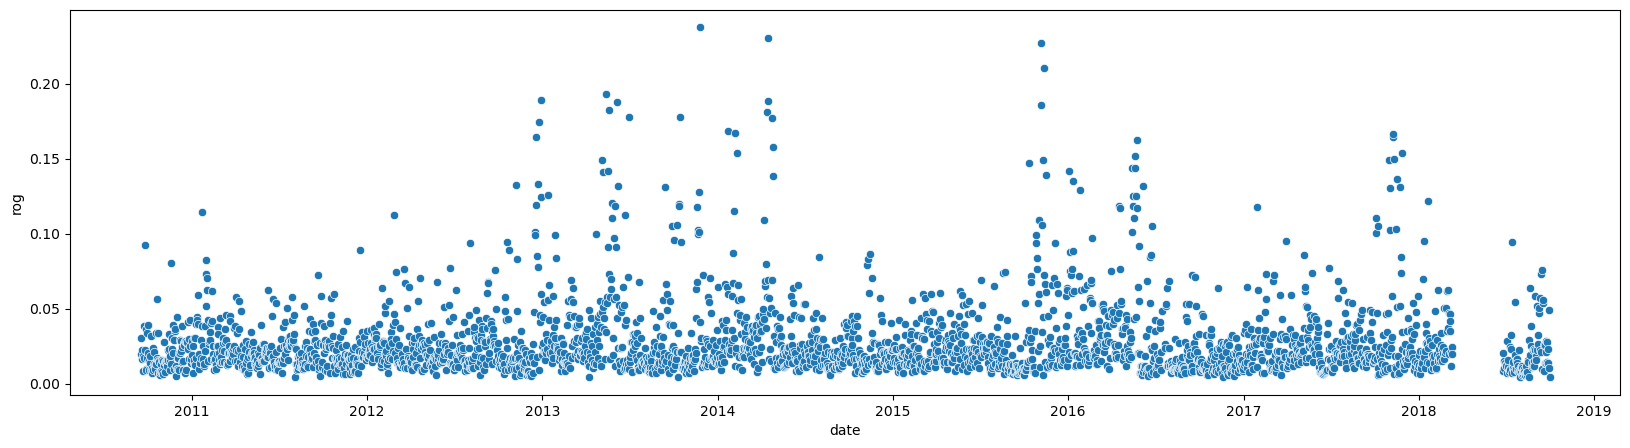

In [25]:
plt.figure(figsize = (20,5))
sns.scatterplot(data = alison_radius_gyration, x="date", y="rog")

## Tesselation as Region-of-Interest (RoI)

Next, we explore spatial tesselation to create a disjoint partition of the whole region into region-of-interest (RoI) using geometric shapes called tiles. We will use a combination of `skmob` and another library called `tesspy` for this.

Using `tesspy`, we get a tessellation of Santa Cruz Island using hexagons.

In [26]:
from tesspy import Tessellation
tessellation = Tessellation("isla santa cruz").hexagons(resolution=8)
# rename hex_id to tile_ID for compatibility with skmob
tessellation.rename(columns={"hex_id": "tile_ID"}, inplace=True)
tessellation.head()

,tile_ID,geometry
0,886c594de9fffff,"POLYGON ((-90.33985 -0.57997, -90.34414 -0.582..."
1,886c594f15fffff,"POLYGON ((-90.32151 -0.50981, -90.32580 -0.512..."
2,886c5bb0adfffff,"POLYGON ((-90.44202 -0.66394, -90.44632 -0.666..."
3,886c5bb403fffff,"POLYGON ((-90.31444 -0.71583, -90.31874 -0.718..."
4,886c5bb207fffff,"POLYGON ((-90.42536 -0.56329, -90.42965 -0.566..."


Each of the rows in the resultant dataframe is a polygon.

In [27]:
type(tessellation["geometry"][0])

shapely.geometry.polygon.Polygon

We can pick the first two polygons and calculate the Hausdorff distance between them:

In [28]:
tessellation.iloc[0].geometry.hausdorff_distance(tessellation.iloc[1].geometry)

0.07252502546087315

We can also visualize what the hexagons look like using `matplotlib`, highlighting the first two polygons in red:

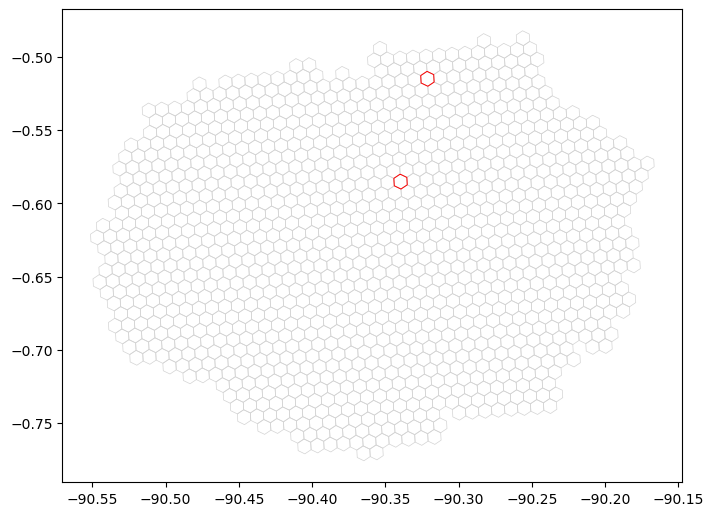

In [29]:
fig, ax = plt.subplots(figsize = (8,8))
tessellation.geometry.boundary.plot(color="lightgrey", ax=ax, linewidth=0.5)
tessellation.iloc[[0,1]].geometry.boundary.plot(color="r", ax=ax,linewidth=0.7)
plt.show()

We can repeat this for two polygons that are next to each other:

In [30]:
hex_sample = tessellation.query("tile_ID == '886c597969fffff' or tile_ID == '886c59796bfffff'")
hex_sample

,tile_ID,geometry
422,886c597969fffff,"POLYGON ((-90.24372 -0.62648, -90.24802 -0.629..."
1061,886c59796bfffff,"POLYGON ((-90.23886 -0.63378, -90.24315 -0.636..."


Compare the Hausdorff distance for these consecutive polygons to the Hausdorff distance for the previous two polygons.

In [31]:
hex_sample.iloc[0].geometry.hausdorff_distance(hex_sample.iloc[1].geometry)

0.008769453529132422

Here is what they look like when plotted in red:

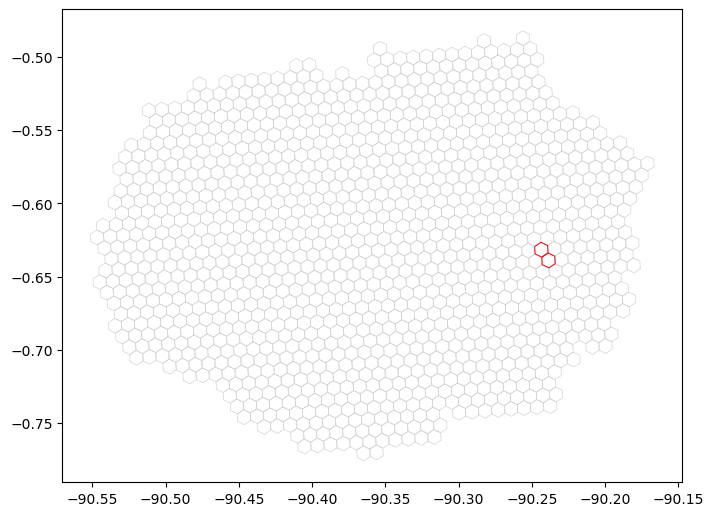

In [32]:
fig, ax = plt.subplots(figsize = (8,8))
tessellation.geometry.boundary.plot(color="lightgrey", ax=ax, linewidth=0.5)
hex_sample.geometry.boundary.plot(color="r", ax=ax,linewidth=0.7)
plt.show()

### Mapping Trajectories into the Tesselation

We can map our `tortoise_trajectory` dataframe from earlier into the tessellation using `skmob`. This assigns each event in the trajectory dataframe to the corresponding tile in the tessellation.

In [33]:
tortoise_trajectory_mapping = tortoise_trajectory.mapping(tessellation)
tortoise_trajectory_mapping

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,tile_ID
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
1290188,46119278,2010-09-17 18:00:58.001,2010-09-17 18:00:58.001000+00:00,2010-09-17 11:00:58.001000-07:00,59,-90.242230,-0.635563,19,0.21,19.01,143.6,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
1290189,46119279,2010-09-17 19:00:56.001,2010-09-17 19:00:56.001000+00:00,2010-09-17 12:00:56.001000-07:00,59,-90.242210,-0.635515,22,0.15,359.14,171.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
1290190,46119280,2010-09-17 20:00:29.000,2010-09-17 20:00:29+00:00,2010-09-17 13:00:29-07:00,59,-90.242227,-0.635356,19,0.75,19.66,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
1290191,46119281,2010-09-17 21:00:56.000,2010-09-17 21:00:56+00:00,2010-09-17 14:00:56-07:00,60,-90.242101,-0.635276,17,0.08,342.75,160.4,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857467,1751004809,2016-06-16 01:00:26.999,2016-06-16 01:00:26.999000+00:00,2016-06-15 18:00:26.999000-07:00,59,-89.682885,-1.371711,12,0.11,16.38,129.0,Chelonoidis hoodensis,Zelfa,2016,6,2016-06-15,NaN
857468,1751004810,2016-06-16 11:00:43.999,2016-06-16 11:00:43.999000+00:00,2016-06-16 04:00:43.999000-07:00,600,-89.682925,-1.371698,10,0.64,245.76,127.3,Chelonoidis hoodensis,Zelfa,2016,6,2016-06-16,NaN
857469,1751004811,2016-06-16 12:00:52.000,2016-06-16 12:00:52+00:00,2016-06-16 05:00:52-07:00,60,-89.682900,-1.371688,9,0.12,285.08,121.8,Chelonoidis hoodensis,Zelfa,2016,6,2016-06-16,NaN
857470,1751004812,2016-06-16 13:00:10.999,2016-06-16 13:00:10.999000+00:00,2016-06-16 06:00:10.999000-07:00,59,-89.682924,-1.371669,10,0.09,34.73,134.9,Chelonoidis hoodensis,Zelfa,2016,6,2016-06-16,NaN


Notice how each event now has an associated `tile_ID`.

As before, there are close to 1.8 million events. We can reduce this number by dropping all events with duplicate dates and `tile_ID` values.

In [34]:
tortoise_trajectory_mapping.drop_duplicates(subset=['date','tile_ID']).shape

(53968, 17)

This reduces the number of events to about 3% of the original.

Let's map the trajectories for Alison to the tessellation:

In [35]:
alison_trajectory_mapping = tortoise_trajectory_mapping.query("uid == 'Alison'")
alison_trajectory_mapping.shape

(40003, 17)

We can drop duplicates here as well, resulting in roughly an 8% reduction.

In [36]:
alison_trajectory_mapping.drop_duplicates(subset=["date", "tile_ID"], inplace=True)
alison_trajectory_mapping.shape

(3254, 17)

Here is what the trajectory mapping for Alison looks like:

In [37]:
alison_trajectory_mapping.head()

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,tile_ID
1290187,46119277,2010-09-17 17:01:25.998,2010-09-17 17:01:25.998000+00:00,2010-09-17 10:01:25.998000-07:00,0,-90.241889,-0.635366,18,0.00,334.23,181.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-17,886c597969fffff
1290196,46119286,2010-09-18 11:00:56.000,2010-09-18 11:00:56+00:00,2010-09-18 04:00:56-07:00,599,-90.242106,-0.635292,6,0.18,3.28,159.3,Chelonoidis donfaustoi,Alison,2010,9,2010-09-18,886c597969fffff
1290211,46119301,2010-09-19 11:01:14.001,2010-09-19 11:01:14.001000+00:00,2010-09-19 04:01:14.001000-07:00,600,-90.242532,-0.635550,6,2.02,175.64,180.1,Chelonoidis donfaustoi,Alison,2010,9,2010-09-19,886c597969fffff
1290226,46119316,2010-09-20 11:01:19.999,2010-09-20 11:01:19.999000+00:00,2010-09-20 04:01:19.999000-07:00,599,-90.242616,-0.635280,6,1.54,172.36,137.3,Chelonoidis donfaustoi,Alison,2010,9,2010-09-20,886c597969fffff
1290241,46119332,2010-09-21 11:00:43.999,2010-09-21 11:00:43.999000+00:00,2010-09-21 04:00:43.999000-07:00,599,-90.242572,-0.635399,6,0.23,330.96,156.2,Chelonoidis donfaustoi,Alison,2010,9,2010-09-21,886c597969fffff


## Additional Exploration

## Stay Location

We can detect stops made by the tortoises using `skmob`'s `stay_location()` function. According to the [documentation](https://scikit-mobility.github.io/scikit-mobility/reference/preprocessing.html#skmob.preprocessing.detection.stay_locations), a stop is defined as occurring when a tortoise spends at least `minutes_for_a_stop` minutes within a radius of `stop_radius_factor` * `spatial_radius` kilometers from a given trajectory point. The resulting coordinates 

We set `minutes_for_a_stop` to 400, meaning that the tortoise must remain in the specified radius for at least 6.66 hours.

In [38]:
tortoise_stay_location = detection.stay_locations(tortoise_trajectory, stop_radius_factor=0.2, minutes_for_a_stop=400,
    spatial_radius_km=0.2, leaving_time=True)
tortoise_stay_location.head()

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,leaving_datetime
0,46120122,2010-11-13 17:00:13.999,2010-11-13 17:00:13.999000+00:00,2010-09-17 10:01:25.998000-07:00,59,-90.242532,-0.635400,14,0.20,355.21,182.5,Chelonoidis donfaustoi,Alison,2010,11,2010-11-13,2010-11-13 10:00:40-08:00
1,46120221,2010-11-20 12:00:33.999,2010-11-20 12:00:33.999000+00:00,2010-11-13 10:00:40-08:00,59,-90.243338,-0.635317,5,0.36,340.13,137.5,Chelonoidis donfaustoi,Alison,2010,11,2010-11-20,2010-11-20 05:00:27-08:00
2,46120252,2010-11-22 13:00:50.000,2010-11-22 13:00:50+00:00,2010-11-20 05:00:27-08:00,59,-90.242979,-0.635375,5,0.21,355.21,164.4,Chelonoidis donfaustoi,Alison,2010,11,2010-11-22,2010-11-22 06:00:43.998000-08:00
3,46121014,2011-01-12 12:00:50.000,2011-01-12 12:00:50+00:00,2010-11-22 06:00:43.998000-08:00,59,-90.243354,-0.635371,10,0.38,354.55,166.1,Chelonoidis donfaustoi,Alison,2011,1,2011-01-12,2011-01-12 05:00:55.998000-08:00
4,46121058,2011-01-15 13:00:27.000,2011-01-15 13:00:27+00:00,2011-01-12 05:00:55.998000-08:00,59,-90.242196,-0.635285,10,0.25,336.20,158.3,Chelonoidis donfaustoi,Alison,2011,1,2011-01-15,2011-01-15 06:00:14-08:00


We can also examine clusters of stopping places:

In [39]:
# cluster stops
tortoise_stay_clusters = clustering.cluster(tortoise_stay_location, cluster_radius_km=0.2, min_samples=1)
tortoise_stay_clusters.head()

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,leaving_datetime,cluster
0,46120122,2010-11-13 17:00:13.999,2010-11-13 17:00:13.999000+00:00,2010-09-17 10:01:25.998000-07:00,59,-90.242532,-0.635400,14,0.20,355.21,182.5,Chelonoidis donfaustoi,Alison,2010,11,2010-11-13,2010-11-13 10:00:40-08:00,1
1,46120221,2010-11-20 12:00:33.999,2010-11-20 12:00:33.999000+00:00,2010-11-13 10:00:40-08:00,59,-90.243338,-0.635317,5,0.36,340.13,137.5,Chelonoidis donfaustoi,Alison,2010,11,2010-11-20,2010-11-20 05:00:27-08:00,1
2,46120252,2010-11-22 13:00:50.000,2010-11-22 13:00:50+00:00,2010-11-20 05:00:27-08:00,59,-90.242979,-0.635375,5,0.21,355.21,164.4,Chelonoidis donfaustoi,Alison,2010,11,2010-11-22,2010-11-22 06:00:43.998000-08:00,1
3,46121014,2011-01-12 12:00:50.000,2011-01-12 12:00:50+00:00,2010-11-22 06:00:43.998000-08:00,59,-90.243354,-0.635371,10,0.38,354.55,166.1,Chelonoidis donfaustoi,Alison,2011,1,2011-01-12,2011-01-12 05:00:55.998000-08:00,1
4,46121058,2011-01-15 13:00:27.000,2011-01-15 13:00:27+00:00,2011-01-12 05:00:55.998000-08:00,59,-90.242196,-0.635285,10,0.25,336.20,158.3,Chelonoidis donfaustoi,Alison,2011,1,2011-01-15,2011-01-15 06:00:14-08:00,1


It seems that some of these locations are much more frequented for stops than others. How might this be related to the tortoises' migration patterns?

In [40]:
tortoise_stay_clusters.cluster.value_counts()

cluster
0     13030
1      2438
2      1184
3       593
4       394
5       293
6       228
7       191
8       168
9       141
10      115
11      103
12       76
13       71
14       61
15       53
16       47
17       43
18       41
19       33
21       31
20       31
22       25
23       21
24       19
26       18
25       18
27       17
28       14
29       13
30       13
31       12
32       10
33        9
34        9
35        8
36        8
37        7
39        6
38        6
43        6
40        6
42        6
41        6
44        5
45        4
46        4
47        4
48        3
55        2
58        2
57        2
56        2
51        2
54        2
53        2
52        2
60        2
50        2
59        2
64        2
61        2
62        2
63        2
65        2
66        2
67        2
49        2
68        1
69        1
70        1
71        1
72        1
Name: count, dtype: int64

We can also take a look at the stay locations for Alison between May 31, 2015 and May 31, 2016:

In [41]:
alison_stay_location = tortoise_stay_location.query("uid == 'Alison'")
alison_stay_location[(alison_stay_location["datetime"] < pd.Timestamp('2016-05-31').tz_localize(tz='US/Pacific')) & \
    (alison_stay_location['datetime'] > pd.Timestamp('2015-05-31').tz_localize(tz = 'US/Pacific'))]

,event_id,timestamp,timestamp_UTC,datetime,minute_diff,lng,lat,eobs_temperature,ground_speed,heading,height_above_ellipsoid,individual_taxon_canonical_name,uid,year,month,date,leaving_datetime
164,917036605,2015-07-03 15:00:27.000,2015-07-03 15:00:27+00:00,2015-06-20 07:00:13.001000-07:00,59,-90.242278,-0.635562,15,0.42,0.66,175.7,Chelonoidis donfaustoi,Alison,2015,7,2015-07-03,2015-07-03 09:00:50.998000-07:00
165,991089390,2015-08-19 16:00:22.998,2015-08-19 16:00:22.998000+00:00,2015-07-03 09:00:50.998000-07:00,60,-90.243278,-0.635550,19,0.09,11.14,40.4,Chelonoidis donfaustoi,Alison,2015,8,2015-08-19,2015-08-19 10:00:57.001000-07:00
166,991089492,2015-08-26 13:00:34.000,2015-08-26 13:00:34+00:00,2015-08-19 10:00:57.001000-07:00,59,-90.241567,-0.636421,8,0.10,332.92,169.8,Chelonoidis donfaustoi,Alison,2015,8,2015-08-26,2015-08-26 07:00:44-07:00
167,1099249203,2015-10-03 17:01:10.001,2015-10-03 17:01:10.001000+00:00,2015-08-26 07:00:44-07:00,59,-90.244269,-0.635823,23,0.49,37.36,166.3,Chelonoidis donfaustoi,Alison,2015,10,2015-10-03,2015-10-03 11:00:43.999000-07:00
168,1099249338,2015-10-12 17:00:56.000,2015-10-12 17:00:56+00:00,2015-10-03 11:00:43.999000-07:00,59,-90.245389,-0.636665,21,0.22,34.73,174.6,Chelonoidis donfaustoi,Alison,2015,10,2015-10-12,2015-10-12 11:00:55.999000-07:00
169,1099249351,2015-10-13 15:00:13.998,2015-10-13 15:00:13.998000+00:00,2015-10-12 11:00:55.999000-07:00,59,-90.247639,-0.634068,14,0.46,9.83,175.5,Chelonoidis donfaustoi,Alison,2015,10,2015-10-13,2015-10-13 09:01:37.998000-07:00
170,1099249412,2015-10-17 16:01:14.998,2015-10-17 16:01:14.998000+00:00,2015-10-13 09:01:37.998000-07:00,60,-90.248289,-0.634437,19,2.54,226.10,133.3,Chelonoidis donfaustoi,Alison,2015,10,2015-10-17,2015-10-17 10:00:57.001000-07:00
171,1099249546,2015-10-26 15:00:40.999,2015-10-26 15:00:40.999000+00:00,2015-10-17 10:00:57.001000-07:00,60,-90.250388,-0.632992,13,0.24,3.28,202.4,Chelonoidis donfaustoi,Alison,2015,10,2015-10-26,2015-10-26 09:01:19.999000-07:00
172,1099249564,2015-10-27 18:00:49.998,2015-10-27 18:00:49.998000+00:00,2015-10-26 09:01:19.999000-07:00,60,-90.252036,-0.631418,28,0.24,3.93,192.9,Chelonoidis donfaustoi,Alison,2015,10,2015-10-27,2015-10-27 12:00:54.999000-07:00
173,1099249589,2015-10-29 13:00:19.999,2015-10-29 13:00:19.999000+00:00,2015-10-27 12:00:54.999000-07:00,59,-90.254425,-0.632729,10,0.42,343.41,206.4,Chelonoidis donfaustoi,Alison,2015,10,2015-10-29,2015-10-29 07:00:50.999000-07:00


We can plot the longitudes of all of Alison's stopping locations with the following code:

<Axes: xlabel='datetime'>

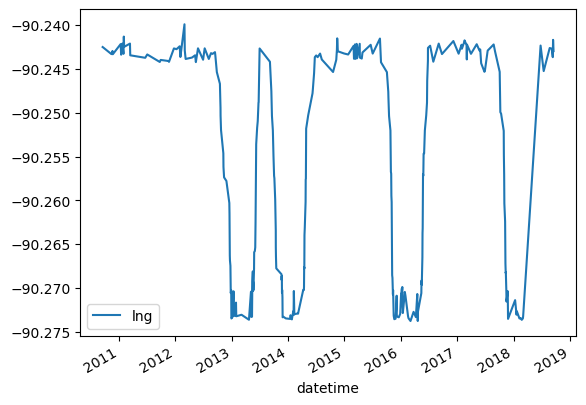

In [42]:
alison_stay_location.plot(x="datetime", y ="lng")

Let's compare this to plots of Alison's longitudes and latitudes with a `ground_speed` less than 1. What do you notice?

<Axes: xlabel='timestamp_local', ylabel='location_long'>

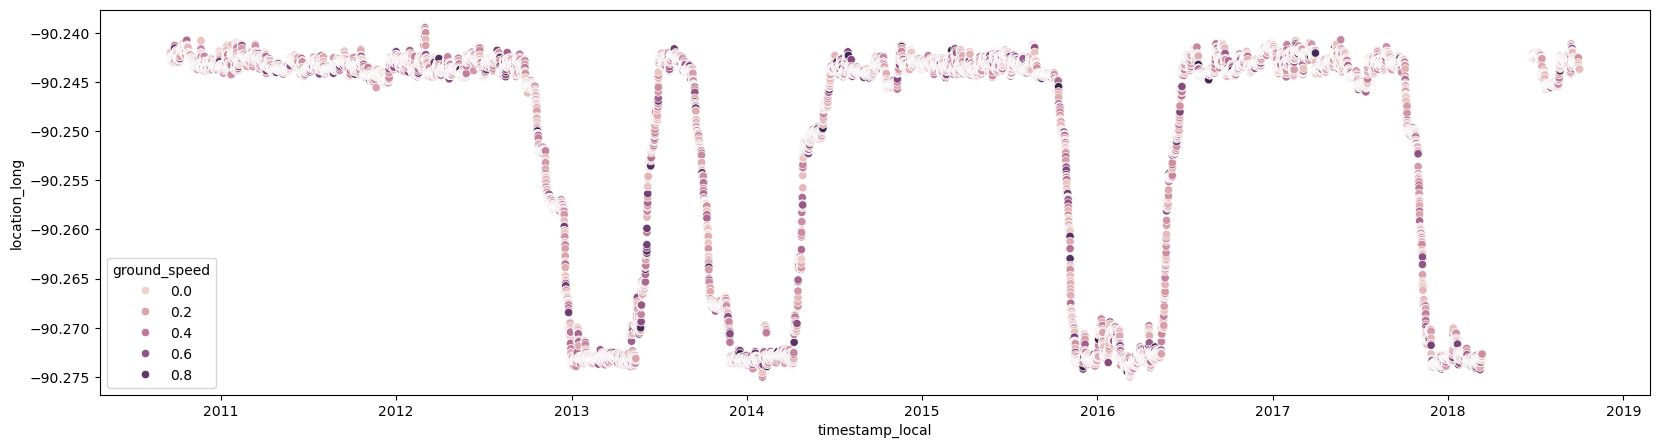

In [43]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_long", hue="ground_speed")

<Axes: xlabel='timestamp_local', ylabel='location_lat'>

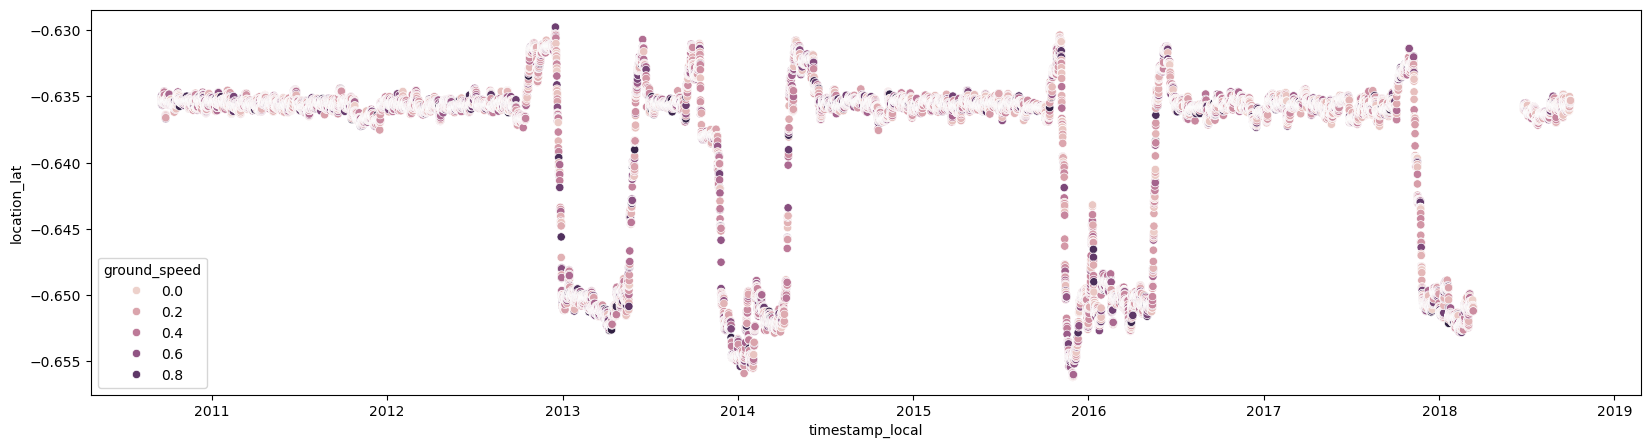

In [44]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison' and ground_speed <1") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="location_lat", hue="ground_speed")

### Maximum Distance and Number of Locations

Using `skmob`'s `maximum_distance()` function, we can find out which tortoises have traveled the farthest.

In [45]:
from skmob.measures.individual import maximum_distance
tortoise_max_distance = maximum_distance(tortoise_trajectory)
tortoise_max_distance

100%|██████████| 96/96 [00:02<00:00, 33.76it/s]


,uid,maximum_distance
0,Alison,3.781776
1,Andrea,1.173420
2,Andres,0.711277
3,Anne,0.688293
4,Bill,1.053307
5,Birgit,0.368320
6,Carolina,1.518231
7,Charles,0.382068
8,Chica,0.560945
9,Chrissie,3.249870


We can also determine the number of distinct locations visited by each tortoise using the `number_of_locations()` function:

In [46]:
from skmob.measures.individual import number_of_locations
tortoise_num_locations = number_of_locations(tortoise_trajectory)
tortoise_num_locations

100%|██████████| 96/96 [00:07<00:00, 12.21it/s]


,uid,number_of_locations
0,Alison,40002
1,Andrea,1519
2,Andres,3739
3,Anne,41109
4,Bill,1814
5,Birgit,28311
6,Carolina,45354
7,Charles,9178
8,Chica,1754
9,Chrissie,25349


We can compare this to the plot of Alison's ground speeds at different times, colored by heading. First, let's look at ground speeds less than 10:

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

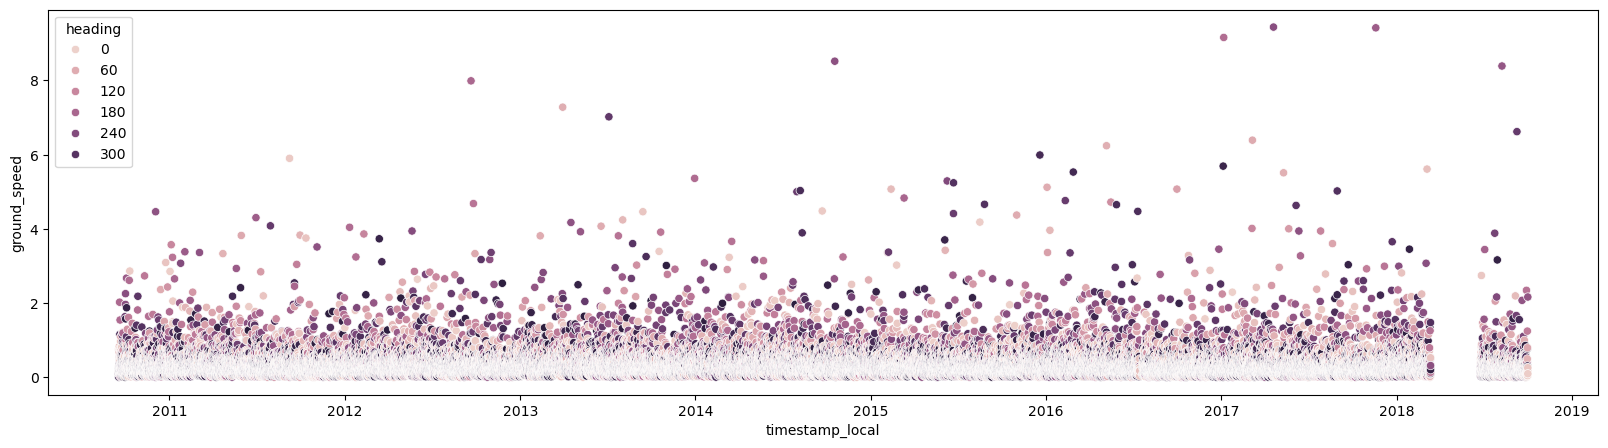

In [47]:
plt.figure(figsize = (20,5))
temp_df = tortoise.query("individual_local_identifier == 'Alison' and ground_speed < 10") # ground_speed unit is meters per second
sns.scatterplot(temp_df, x = "timestamp_local", y="ground_speed", hue="heading")


Then let's compare it to all of Alison's ground speeds:

<Axes: xlabel='timestamp_local', ylabel='ground_speed'>

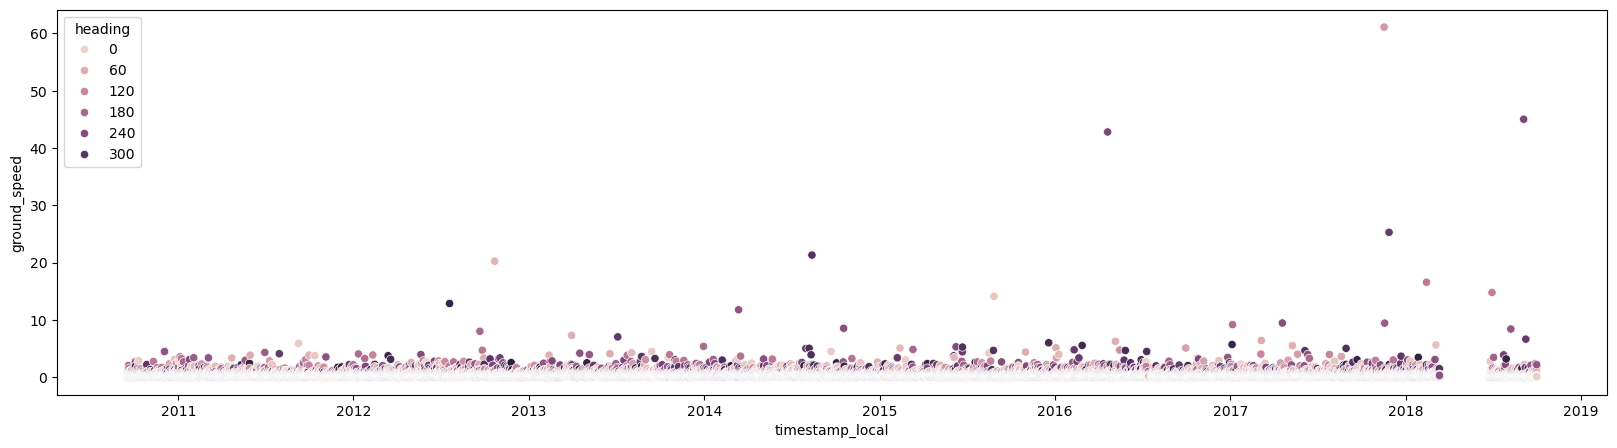

In [48]:
plt.figure(figsize = (20,5))
alison = tortoise.query("individual_local_identifier == 'Alison'") # ground_speed unit is meters per second
sns.scatterplot(alison, x = "timestamp_local", y="ground_speed", hue="heading")